In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

In [2]:
# Load dataset train loan dataset
train_df = pd.read_csv("train_loan_dataset.csv")

# Data Preprocessing
train_df.drop('Loan_ID', axis=1, inplace=True)

# Handle missing values
cat_cols = train_df.select_dtypes(include='object').columns.drop('Loan_Status')
num_cols = train_df.select_dtypes(exclude='object').columns

# For categorical columns
for col in cat_cols:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

# For numerical columns
for col in num_cols:
    train_df[col] = train_df[col].fillna(train_df[col].median())

# Encode categorical variables
le = LabelEncoder()
for col in cat_cols:
    train_df[col] = le.fit_transform(train_df[col])
train_df['Loan_Status'] = le.fit_transform(train_df['Loan_Status'])  # Y=1, N=0

# Split data
X = train_df.drop('Loan_Status', axis=1)
y = train_df['Loan_Status']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)



In [3]:
# Train Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predictions
train_preds = nb_model.predict(X_train)
val_preds = nb_model.predict(X_val)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, train_preds)
val_accuracy = accuracy_score(y_val, val_preds)

print("Training Accuracy:", train_accuracy)
print("Validation Accuracy:", val_accuracy)

Training Accuracy: 0.7922606924643585
Validation Accuracy: 0.8455284552845529


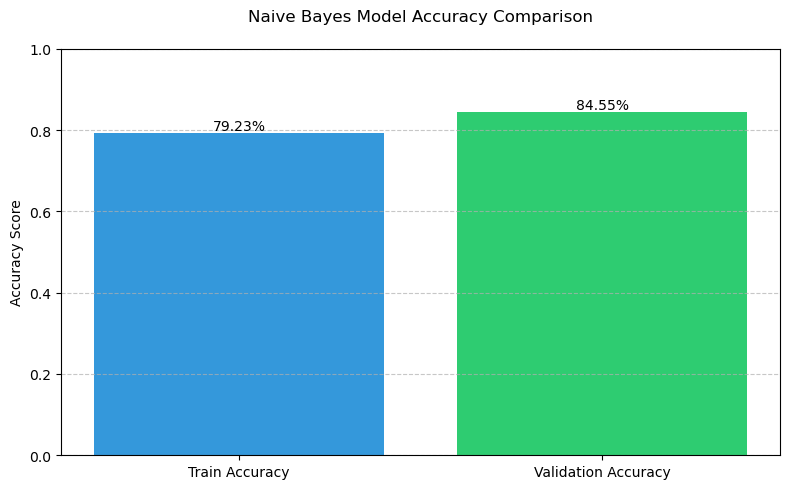

In [4]:
import matplotlib.pyplot as plt

# Data for plotting
accuracies = [train_accuracy, val_accuracy]
labels = ['Train Accuracy', 'Validation Accuracy']
colors = ['#3498db', '#2ecc71']

# Create bar plot
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accuracies, color=colors)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2%}', ha='center', va='bottom')

# Customize plot
plt.title('Naive Bayes Model Accuracy Comparison', pad=20)
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()

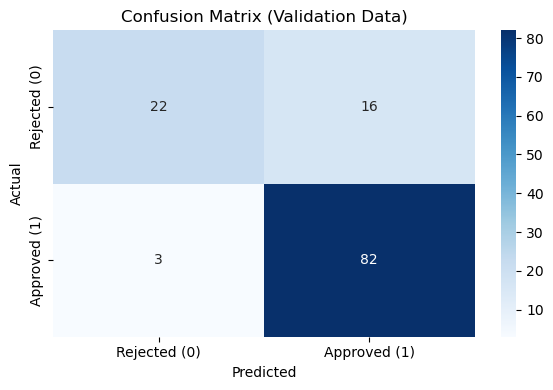

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_val, val_preds)

# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
plt.title('Confusion Matrix (Validation Data)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [8]:
#import numpy as np

# Get feature importance (absolute difference in class means)
#if hasattr(nb_model, 'theta_'):
    #feature_importance = np.abs(nb_model.theta_[1] - nb_model.theta_[0])
    #sorted_idx = np.argsort(feature_importance)[::-1]

    #plt.figure(figsize=(10, 6))
    #plt.barh(X.columns[sorted_idx], feature_importance[sorted_idx], color='#9b59b6')
    #plt.title('Feature Importance (Naive Bayes)')
    #plt.xlabel('Importance Score (|μ₁ - μ₀|)')
    #plt.tight_layout()
    #plt.show()

In [7]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load test dataset
test_df = pd.read_csv("test_loan_dataset.csv")  # Assuming test dataset filename

# Keep Loan_ID for reference
loan_ids = test_df['Loan_ID'].copy()

# Initialize a dictionary to store label encoders (if not already done in training)
label_encoders = {}

# Preprocess test data using the same pipeline as training
def preprocess_data(df):
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # Drop Loan_ID (we'll add it back later)
    if 'Loan_ID' in df.columns:
        df.drop('Loan_ID', axis=1, inplace=True)
    
    # Handle missing values - same as training
    cat_cols = df.select_dtypes(include='object').columns
    num_cols = df.select_dtypes(exclude='object').columns
    
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    
    # Encode categorical variables - create the same encoders as in training
    for col in cat_cols:
        if col not in label_encoders:
            # This is a fallback - save/load the encoders from training
            label_encoders[col] = LabelEncoder()
            # Fit on all possible categories
            label_encoders[col].fit(df[col])
        df[col] = label_encoders[col].transform(df[col])
    
    return df

# Preprocess test data
X_test = preprocess_data(test_df)

# Make predictions
test_predictions = nb_model.predict(X_test)
test_probabilities = nb_model.predict_proba(X_test)[:, 1]  # Probability of approval (class 1)

# Decode predictions (assuming you have Loan_Status encoder)
if 'Loan_Status' not in label_encoders:
    label_encoders['Loan_Status'] = LabelEncoder().fit(['Y', 'N'])  # Fallback

test_results = pd.DataFrame({
    'Loan_ID': loan_ids,
    'Predicted_Status': label_encoders['Loan_Status'].inverse_transform(test_predictions),
    'Approval_Probability': test_probabilities,
    'Confidence_Level': pd.cut(test_probabilities,
                              bins=[0, 0.5, 0.7, 1],
                              labels=['low', 'medium', 'high'])
})

# Add original features for analysis
test_results = pd.concat([test_results, test_df.reset_index(drop=True)], axis=1)

# Save predictions to CSV
test_results.to_csv('loan_predictions.csv', index=False)

# If actual labels are available (for evaluation)
try:
    y_test = label_encoders['Loan_Status'].transform(test_df['Loan_Status'])
    
    print("\nModel Evaluation on Test Set:")
    print("Accuracy:", accuracy_score(y_test, test_predictions))
    print("\nClassification Report:")
    print(classification_report(y_test, test_predictions, 
                              target_names=['Rejected', 'Approved']))
    
    # Confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, test_predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Rejected', 'Approved'],
                yticklabels=['Rejected', 'Approved'])
    plt.title('Test Set Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    # Probability distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(data=test_results, x='Approval_Probability', hue='Predicted_Status',
                 bins=20, kde=True, palette=['red', 'green'])
    plt.title('Approval Probability Distribution')
    plt.xlabel('Approval Probability')
    plt.ylabel('Count')
    plt.axvline(0.5, color='black', linestyle='--')
    plt.show()
    
except KeyError:
    print("\nNo ground truth labels in test set. Predictions saved to 'loan_predictions.csv'")

# Display sample predictions
print("\nSample Predictions:")
print(test_results[['Loan_ID', 'Predicted_Status', 'Approval_Probability', 'Confidence_Level']].head(5))


No ground truth labels in test set. Predictions saved to 'loan_predictions.csv'

Sample Predictions:
    Loan_ID   Loan_ID Predicted_Status  Approval_Probability Confidence_Level
0  LP001015  LP001015                Y              0.948033             high
1  LP001022  LP001022                Y              0.956953             high
2  LP001031  LP001031                Y              0.961367             high
3  LP001035  LP001035                Y              0.954960             high
4  LP001051  LP001051                Y              0.890811             high
